# Peak-productivity windows
Explains how each peak-productivity window was dated and at what age individuals flourished.

In [1]:
import tempfile
import numpy as np
import polars as pl
import duckdb
import matplotlib.pyplot as plt
from style import *

SEED = 42
np.random.seed(SEED)

DB_PATH = '../data/cultura/humans_clean_v2.duckdb'
CV_DB_PATH = '../data/similar_databases/cross_verified.duckdb'
YEAR_OR_FINER = ('day', 'month', 'year')
BIN_WIDTH = 50
LAST_COMPLETE_BIN = 1950

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(12)
pl.Config.set_fmt_str_lengths(60)
pl.Config.set_tbl_width_chars(220)

apply_style()

## External data — Cross-Verified occupations

In [2]:
cv_con = duckdb.connect(CV_DB_PATH, read_only=True)
cv_occupations = cv_con.sql("""
    SELECT
        wikidata_code AS qid,
        level1_main_occ
    FROM individuals
    WHERE wikidata_code IS NOT NULL
      AND level1_main_occ IS NOT NULL
""").pl()
cv_con.close()
assert cv_occupations['qid'].n_unique() == cv_occupations.height
print('cv_occupations:', cv_occupations.shape)

cv_occupations: (2291817, 2)


## Load data

In [3]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql(f"SET memory_limit='4GB'; SET threads=6; SET temp_directory='{tempfile.mkdtemp()}';")
con.sql("CREATE TEMP MACRO from_llm(d) AS coalesce(d.field_provenance['year'].ai_answer.prompt_id = 'wikipedia_dates', false)")

### Age at floruit

In [4]:
floruit_birth_pairs = con.sql("""
    SELECT
        entity.qid             AS qid,
        floruit_date[1].year   AS floruit_year,
        birth_date[1].year     AS birth_year
    FROM individual
    WHERE list_contains($year_or_finer, floruit_date[1].precision)
      AND NOT from_llm(floruit_date[1])
      AND list_contains($year_or_finer, birth_date[1].precision)
      AND NOT from_llm(birth_date[1])
""", params={'year_or_finer': list(YEAR_OR_FINER)}).pl()
con.close()

assert floruit_birth_pairs['qid'].n_unique() == floruit_birth_pairs.height
print('shape:', floruit_birth_pairs.shape)
floruit_birth_pairs.head()

shape: (16525, 3)


qid,floruit_year,birth_year
str,i64,i64
"""Q106582465""",1933,1900
"""Q106593712""",1945,1915
"""Q110295343""",1729,1707
"""Q110295485""",1755,1733
"""Q106644110""",1973,1952


## Preprocessing
### Method category

### Age at floruit (10–100 years)

In [5]:
AGE_MIN, AGE_MAX = 10, 100

age_at_floruit = (
    floruit_birth_pairs
    .with_columns((pl.col('floruit_year') - pl.col('birth_year')).alias('age_at_floruit'))
    .filter(pl.col('age_at_floruit').is_between(AGE_MIN, AGE_MAX))
)
print(f'rows: {floruit_birth_pairs.height:,} -> {age_at_floruit.height:,} (kept ages {AGE_MIN}–{AGE_MAX})')
age_at_floruit.head()

rows: 16,525 -> 15,833 (kept ages 10–100)


qid,floruit_year,birth_year,age_at_floruit
str,i64,i64,i64
"""Q106582465""",1933,1900,33
"""Q106593712""",1945,1915,30
"""Q110295343""",1729,1707,22
"""Q110295485""",1755,1733,22
"""Q106644110""",1973,1952,21


In [6]:
SHOW_OCCUPATIONS = list(OCCUPATION_COLORS)

age_at_floruit_by_occupation = (
    age_at_floruit.join(cv_occupations, on='qid', how='inner')
    .filter(pl.col('level1_main_occ').is_in(SHOW_OCCUPATIONS))
)
print(f'matched to a CV occupation: {age_at_floruit_by_occupation.height:,}')
age_at_floruit_by_occupation.group_by('level1_main_occ').len().sort('len', descending=True)

matched to a CV occupation: 3,930


level1_main_occ,len
str,u32
"""Culture""",3074
"""Discovery/Science""",345
"""Leadership""",294
"""Sports/Games""",217


### Age at floruit per bucket

In [7]:
MIN_BIN_N = 10

def age_per_bucket(df, by=()):
    return (
        df.filter(pl.col('floruit_year') < LAST_COMPLETE_BIN + BIN_WIDTH)
        .with_columns((pl.col('floruit_year') // BIN_WIDTH * BIN_WIDTH).alias('bucket'))
        .group_by(*by, 'bucket')
        .agg(pl.len().alias('n'),
             pl.col('age_at_floruit').median().alias('median'),
             pl.col('age_at_floruit').quantile(0.25).alias('q25'),
             pl.col('age_at_floruit').quantile(0.75).alias('q75'))
        .filter(pl.col('n') >= MIN_BIN_N)
        .sort(*by, 'bucket')
    )

age_per_century = age_per_bucket(age_at_floruit)
age_per_bin_by_occupation = age_per_bucket(age_at_floruit_by_occupation, by=('level1_main_occ',))
print('overall:', age_per_century.shape, '| per occupation:', age_per_bin_by_occupation.shape)
age_per_century.head()

overall: (14, 5) | per occupation: (24, 6)


bucket,n,median,q25,q75
i64,u32,f64,f64,f64
1250,10,49.5,21.0,60.0
1350,12,29.5,21.0,30.0
1400,22,35.0,27.0,54.0
1450,35,43.0,32.0,56.0
1500,62,34.5,25.0,55.0


## Figures
### Fig 1 — Assignation methods

### Figure 3A — Median age at floruit per century

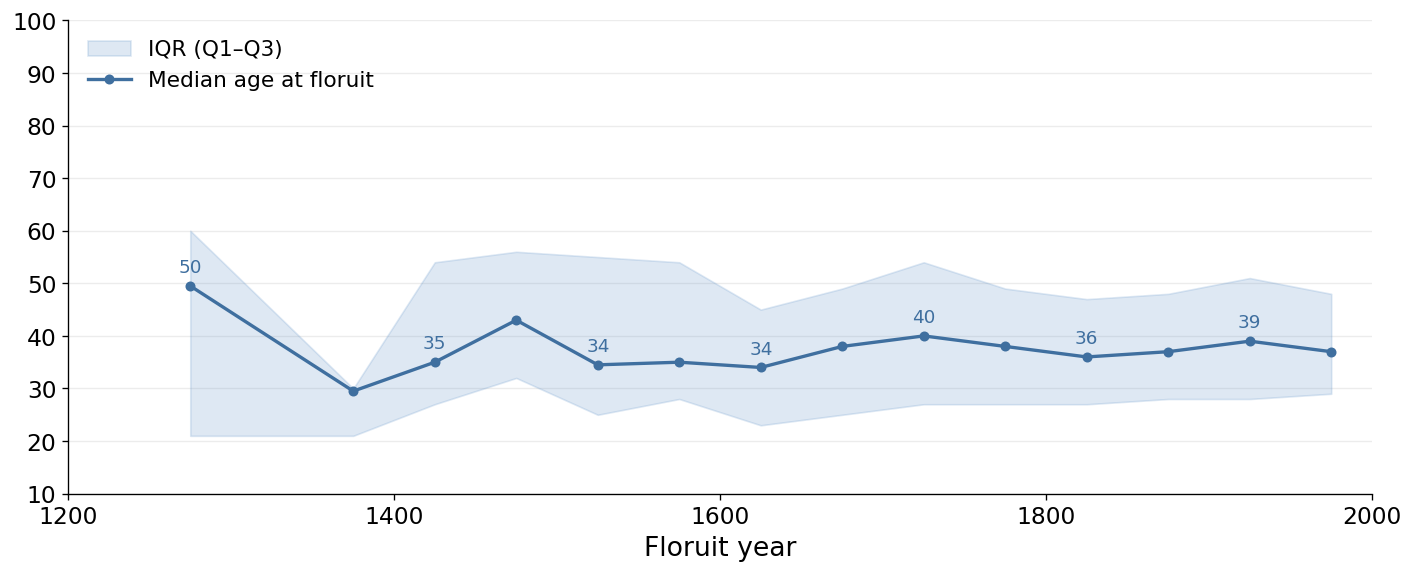

In [8]:
xs = age_per_century['bucket'].to_numpy() + BIN_WIDTH / 2
median = age_per_century['median'].to_numpy()

fig, ax = plt.subplots()
ax.fill_between(xs, age_per_century['q25'], age_per_century['q75'], color=MAIN_COLOR, alpha=BAND_ALPHA, label='IQR (Q1–Q3)')
ax.plot(xs, median, color=MAIN_LINE_COLOR, marker='o', ms=5, label='Median age at floruit')
for i, (x, m) in enumerate(zip(xs, median)):
    if i % 2 == 0:
        ax.annotate(f'{m:.0f}', (x, m), xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=POINT_LABEL_FONTSIZE, color=MAIN_LINE_COLOR)
first = int(age_per_century['bucket'].min() // 100 * 100)
ax.set_xticks(range(first, LAST_COMPLETE_BIN + BIN_WIDTH + 1, 200))
ax.set_xlim(first, LAST_COMPLETE_BIN + BIN_WIDTH)
ax.set_ylim(AGE_MIN, AGE_MAX)
ax.set_xlabel('Floruit year')
ax.grid(axis='y')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Figure 3B — Median age at floruit per century, by occupational category

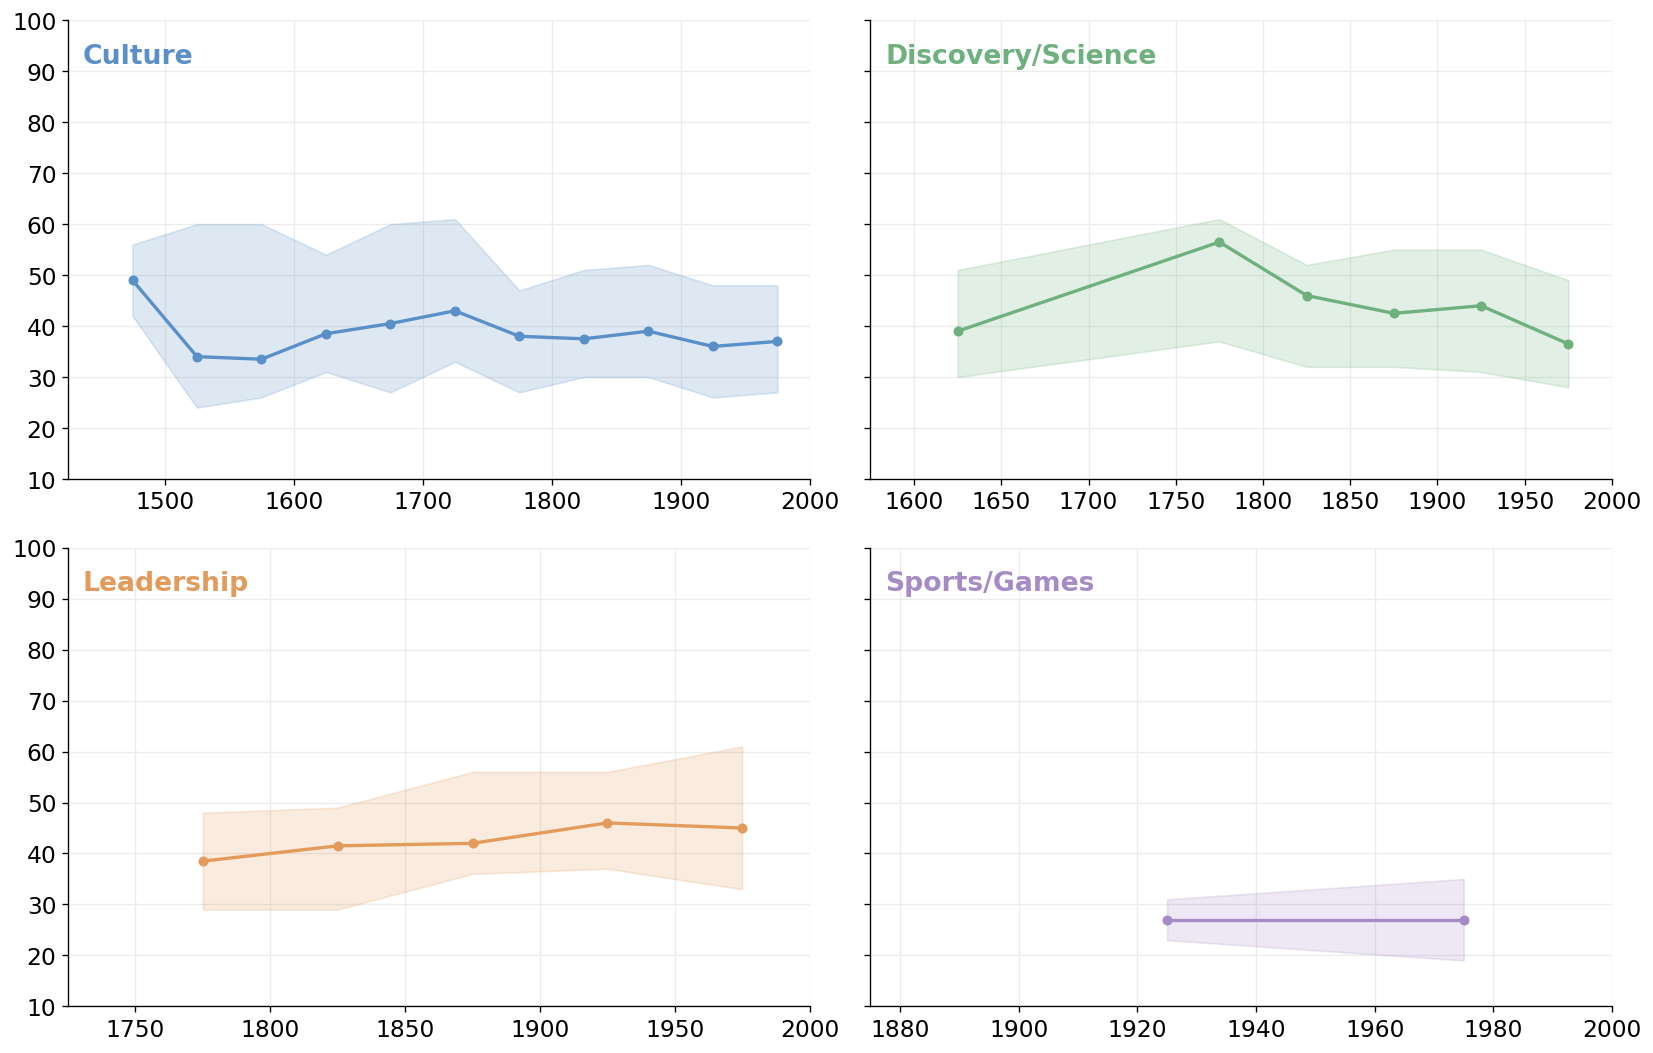

In [9]:
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_GRID, sharey=True)
for ax, (occupation, color) in zip(axes.flat, OCCUPATION_COLORS.items()):
    sub = age_per_bin_by_occupation.filter(pl.col('level1_main_occ') == occupation)
    x = sub['bucket'].to_numpy() + BIN_WIDTH / 2
    ax.fill_between(x, sub['q25'], sub['q75'], color=color, alpha=BAND_ALPHA)
    ax.plot(x, sub['median'], color=color, marker='o', ms=5)
    ax.set_xlim(x.min() - BIN_WIDTH, LAST_COMPLETE_BIN + BIN_WIDTH)
    ax.set_ylim(AGE_MIN, AGE_MAX)
    ax.text(0.02, 0.95, occupation, transform=ax.transAxes, fontsize=PANEL_LABEL_FONTSIZE, color=color, va='top', fontweight='bold')
    ax.grid(True)
plt.tight_layout()
plt.show()